# Импорт библиотек

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

#подключены все необходимые библиотеки

# Загрузка и первичных данных с сбросом лишних столбцов

In [ ]:
df = pd.read_csv("bank.csv")

print(f"Размер датасета : {df.shape[0]} клиентов и {df.shape[1]} признаков")
print(df.columns)
df.info()

# Убрали данные столбцы, так как они не несут полезной информации для долгосрочного прогнозирования
df = df.drop(["day", "month", "contact"], axis=1)

marital_stats = df.groupby("marital")[["age", "balance"]].mean()
print("\nСредний возраст и баланс на карте в зависимости от семейного положения:\n", marital_stats)

df['deposit'] = df['deposit'].map({'yes': 1, 'no': 0})

print("\nПервые 3 строки данных")
df.head(3)

# Вывод: данные успешно загружены, удалены неинформативные столбцы, рассчитаны средний возраст и баланс по группам семейного положения, а целевой признак deposit переведен в бинарный числовой формат.

Размер датасета : 11162 клиентов и 17 признаков
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null 

,age,job,marital,education,default,balance,housing,loan,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,1042,1,-1,0,unknown,1
1,56,admin.,married,secondary,no,45,no,no,1467,1,-1,0,unknown,1
2,41,technician,married,secondary,no,1270,yes,no,1389,1,-1,0,unknown,1


# Визуализация данных через график "усатой коробки"

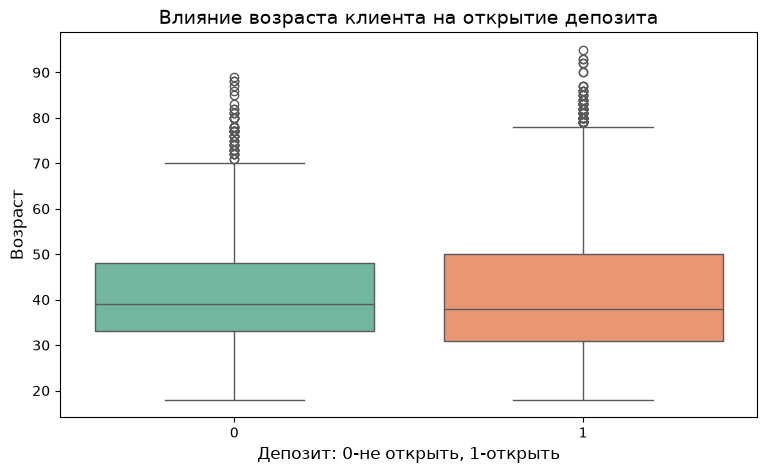

In [ ]:
plt.figure(figsize=(9, 5))

sns.boxplot(x="deposit", y="age", data=df, palette="Set2", legend=False, hue="deposit")
plt.title("Влияние возраста клиента на открытие депозита", fontsize=14)
plt.xlabel("Депозит: 0-не открыть, 1-открыть", fontsize=12)
plt.ylabel("Возраст", fontsize=12)
plt.show()

# Вывод: график типа «ящик с усами» позволяет наглядно сравнить распределение возраста клиентов и показывает, что по возрасту мы не можем определить процент открытия депозита.

# Подготовка признаков для обучения

In [ ]:
y = df["deposit"]

x = pd.get_dummies(df.drop("deposit", axis=1), columns=["education", "marital", "loan", "housing", "job", "default", "previous", "poutcome", "pdays"], drop_first=True)

print("Данные после обработки категоральных признаков")
x.head(3)

# Вывод: целевая переменная отделена от матрицы признаков, а категориальные столбцы закодированы для подачи в модель.

Данные после обработки категоральных признаков


,age,balance,duration,campaign,education_secondary,education_tertiary,education_unknown,marital_married,marital_single,loan_yes,...,pdays_778,pdays_782,pdays_784,pdays_792,pdays_804,pdays_805,pdays_826,pdays_828,pdays_842,pdays_854
0,59,2343,1042,1,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,56,45,1467,1,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,41,1270,1389,1,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


# Масштабирование и разбиение данных для обучения

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, train_size=0.2, random_state=42, stratify=y
)

numeric_cols = [
    "age",
    "balance",
    "duration",
    "campaign",
]
scaler = StandardScaler()
x_train[numeric_cols] = scaler.fit_transform(x_train[numeric_cols])
x_test[numeric_cols] = scaler.fit_transform(x_test[numeric_cols])
x_train.head(3)

# Вывод: датасет корректно разбит на обучающую и тестовую выборки с сохранением баланса классов, а числовые признаки приведены к единому масштабу.

,age,balance,duration,campaign,education_secondary,education_tertiary,education_unknown,marital_married,marital_single,loan_yes,...,pdays_778,pdays_782,pdays_784,pdays_792,pdays_804,pdays_805,pdays_826,pdays_828,pdays_842,pdays_854
4850,-1.402801,0.334334,-0.430529,1.771346,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
7034,1.502968,-0.255210,-0.729113,-0.170522,False,True,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
2185,0.562866,0.892376,-0.463705,-0.170522,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


# Обучение модели и оценка взятия депозита

In [ ]:
model = RandomForestClassifier(
    n_estimators=100, random_state=42, class_weight="balanced"
)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"Общая точность модели (Accuracy): {accuracy:.2f}%\n")

# Вывод: модель успешно обучена, и мы узнали точность потенциальных вкладчиков банка, составившую около 79.1%.

Общая точность модели (Accuracy): 79.10%

